# Project Final Report
### Due: Midnight on April 27th — 50 points

---

## 1. Executive Summary [4 pts]

**1.1 Answer:**

We worked with a dataset of **72,332 residential properties** across Los Angeles County, all assessed in 2016. Think of the data as a big spreadsheet where each row is a house, and each column tells you something about it — how big it is, how many bedrooms and bathrooms it has, what year it was built, where it's located, and a bunch of other details. The number we were trying to predict is the officially assessed tax value of each property.

We tested three types of prediction models, ranging from a simple formula-based approach all the way up to a more sophisticated one that builds hundreds of decision trees and averages their guesses. That last one — called a **Random Forest** — was the clear winner. On average, it predicted a home's assessed value within about **$135,137** of the actual figure. That might sound like a lot, but keep in mind these are LA County properties, where the market spans from modest condos to multi-million dollar estates. Compared to our other models, this was meaningfully more accurate.

The model also confirmed some intuitions you'd expect any experienced agent to already have: **square footage matters most**. Lot size and the age of the property are close behind. Location-related features (zip code, neighborhood ID, latitude/longitude) showed up consistently as important too.

Our recommendation would be to use the Random Forest model as a first-pass automated valuation tool. It's not a replacement for an experienced appraiser, but it can do a solid job of flagging properties that look over- or under-priced relative to their physical characteristics. With fresher data and a few refinements, there's a real opportunity to make this model even more useful.

## 2. Introduction [3 pts]

**2.1 Answer:**

### Context

Walk into any real estate office and you'll find analysts spending chunks of their day doing the same thing over and over: looking up comparable properties, adjusting for square footage here, accounting for a renovated kitchen there, and eventually landing on a number that feels right. It works, but it's slow, it's expensive, and it varies from person to person. Automated Valuation Models (AVMs) offer a more scalable path — feed a model the observable characteristics of a property, and it spits out an estimate in seconds, applying the same logic every single time.

### Problem Statement

The company doesn't currently have a systematic, reproducible way to estimate residential property values from raw data. Analysts rely on judgment and manual comparables, which creates inconsistency — two analysts might arrive at very different numbers for the same property. We need a model that can close that gap.

The specific target we're predicting is `taxvaluedollarcnt`: the officially assessed tax value of each residential property in our dataset, in US dollars.

### Motivation

Getting valuations right has direct financial consequences. Overpay on an acquisition and you're underwater before you've done anything. Underprice a listing and you've handed value to the buyer. A model that can catch these errors — or at least flag them for a second look — has real business value.

### Objectives

1. Build and rigorously evaluate multiple regression models to predict residential property tax value from structured property data.
2. Identify which features are the most powerful and consistent predictors of assessed value.
3. Select and validate a final model suitable for deployment as a baseline valuation tool.
4. Surface findings that can inform the company's broader data and tooling strategy — not just this single use case.

The analysis follows a standard supervised learning pipeline: clean the data, engineer new features, compare models using cross-validation, tune hyperparameters, and evaluate the final winner on a held-out test set it has never seen before.

## 3. Data Description [3 pts]

**3.1 Answer:**

### Source

The dataset comes from a publicly hosted Zillow property file maintained by Boston University (`cs.bu.edu/fac/snyder/cs505/Data/zillow_dataset.csv`). It covers residential properties in **Los Angeles County assessed in 2016** — a snapshot of the market at a specific point in time.

### Dataset at a Glance

| Attribute | Value |
|---|---|
| Raw observations | ~90,000+ |
| After cleaning | **72,332 properties** |
| Features (after cleaning) | **61 columns** |
| Training set | 57,865 rows |
| Test set | 14,467 rows |
| Target variable | `taxvaluedollarcnt` |

### Feature Types

- **Numeric continuous:** calculated finished square footage, lot size, latitude/longitude, year built, bathroom count, bedroom count, room count, garage square footage
- **Numeric categorical (encoded):** AC type ID, heating system type ID, building quality type ID, property use type ID, unit count, FIPS code, zip code, city/neighborhood region IDs
- **Identifiers (dropped):** parcel ID, census tract, county land use code — no predictive signal for a generalizable model

### Target Variable

`taxvaluedollarcnt` is the assessed tax value in US dollars. It's right-skewed (lots of average homes, a tail of expensive ones), which influenced our preprocessing choices.

### Key Data Issues

- Several columns were missing **more than 70% of their values** (pool-related features, building condition flags) and were dropped entirely
- The target variable had a strong right skew with extreme outliers that would have distorted model training — addressed with IQR filtering
- Garage-related columns had high missingness but the absence most plausibly means "no garage" — filled with zero rather than dropped
- High-cardinality location identifiers (zip code, city region, neighborhood ID) were retained after encoding but showed mixed utility across models

## 4. Methodology (What you did, and why) [20 pts]

### 4.1 Analytical Framework

**4.1 Answer:**

The overall approach was deliberately sequential: start simple, measure everything, and only add complexity when the numbers justify it. Every decision — which features to add, which model to tune, which hyperparameters to search — was driven by cross-validated error scores rather than gut feeling.

**Train/Test Split:** We split the cleaned dataset 80/20, putting 57,865 rows into training and locking away 14,467 as a held-out test set. That test set was touched exactly once, at the very end. During development, it didn't exist as far as our models were concerned.

**Cross-Validation:** All model evaluation during development used **Repeated K-Fold CV (5 folds × 5 repeats = 25 distinct train/validation configurations)**. This gives a far more reliable estimate of out-of-sample performance than a single split — especially important when you're comparing models that might differ by only a few thousand dollars in MAE.

**Validation Curves:** For tree-based models (Decision Tree and Random Forest), we used validation curves to understand how hyperparameters like `max_depth` affect the bias-variance tradeoff. This let us set sensible search ranges before running expensive grid searches.

**Why MAE over RMSE:** Mean Absolute Error is expressed in the same units as the target (US dollars), which makes it directly interpretable. An MAE of $135,000 means the model is off by $135,000 on average — easy to communicate to a non-technical audience. RMSE disproportionately penalizes large errors, and we didn't want a handful of unusual luxury properties to dominate every tuning decision. MAE was the cleaner choice for this problem.

### 4.2 Data Cleaning and Preprocessing

**4.2 Answer:**

The raw Zillow data was messy in the way most real-world datasets are — lots of missing values, some columns that weren't useful, and a target variable with a tail long enough to cause problems. Here's what we did about it:

**Dropped columns:** Administrative identifiers (parcel ID, census tract, assessment year) were removed — they'd memorize the training set without generalizing at all. Any feature missing more than 70% of its values was also dropped; you can't impute your way out of that much missingness without just making stuff up.

**Dropped rows:** Any row missing the target variable was removed immediately (nothing to predict against). We also filtered out rows missing more than 50% of their own features.

**Outlier removal:** The target variable `taxvaluedollarcnt` had extreme right-skew. We applied the IQR method — keeping only values within 1.5 × IQR of Q1 and Q3 — which trimmed the most extreme properties without discarding the bulk of the data. This made model training noticeably more stable.

**Imputation strategy:**
- Garage columns (`garagecarcnt`, `garagetotalsqft`) → filled with **zero** (missing most plausibly means no garage)
- Categorical columns → filled with **column mode**
- Numeric columns → filled with **column median**

**Encoding:** Low-cardinality categorical features (AC type, heating type, property use type, FIPS code) were one-hot encoded using `pd.get_dummies` with `drop_first=True`.

**Standardization:** All numeric features were standardized using `StandardScaler` **fit only on the training data**. This is a critical step — fitting the scaler on the full dataset would leak test set information into training. The scaler was re-fit whenever new engineered features were added.

What worked well: the IQR trim and the zero-fill for garage columns both led to cleaner model behavior. What had less impact: mode imputation for high-cardinality location IDs introduced some noise, and those features were often dropped during feature selection anyway.

### 4.3 Feature Engineering

**4.3 Answer:**

We went from 61 original features to **68 features** by adding seven engineered ones, all grounded in domain reasoning about what actually drives property value:

| New Feature | How it's built | Why it might help |
|---|---|---|
| `log_calculatedfinishedsquarefeet` | log(finished sqft) | Reduces right-skew; helps linear models |
| `log_lotsizesquarefeet` | log(lot size) | Same rationale |
| `total_sqft` | finished sqft + lot sqft | Overall property scale in one number |
| `sqft_per_bedroom` | finished sqft ÷ bedroom count | Captures space density / efficiency |
| `sqft_x_bathrooms` | finished sqft × bathrooms | Interaction: large home + more baths = disproportionate value |
| `property_age` | 2016 − year built | Makes depreciation explicit |
| `total_bath_bed` | bathrooms + bedrooms | Quick proxy for overall dwelling size |

**What worked:** `total_sqft`, `property_age`, and `sqft_x_bathrooms` were consistently retained during feature selection and appeared in the top-k subsets for both tree-based models. These are the keepers.

**What had limited impact:** `total_bath_bed` was largely redundant once the individual bedroom and bathroom counts were already in the dataset. Adding it didn't hurt, but it didn't help much either.

**Interesting observation:** Feature engineering improved Linear Regression slightly ($149,599 → $149,261 MAE) but actually *slightly increased* MAE for Decision Tree and Random Forest at the default parameter stage. This is worth noting — more features aren't always better, especially for tree models that already capture interactions naturally. The engineered features became more valuable after tuning.

### 4.4 Model Selection

**4.4 Answer:**

We chose three models to span a range of complexity and interpretability:

**1. Linear Regression / Ridge:** The linear baseline. Simple, fast, and interpretable. Ridge was substituted during tuning since plain Linear Regression has no meaningful hyperparameters. Ridge's `alpha` controls how aggressively it shrinks coefficients — useful when correlated features are present (and we had plenty). Best alpha found: **0.01**.

**2. Decision Tree:** A nonlinear model that partitions the feature space recursively. Highly interpretable (you can actually draw the tree) but prone to overfitting without regularization. Best hyperparameters found: `max_depth=10`, `min_samples_leaf=8`, `min_samples_split=20`.

**3. Random Forest:** An ensemble of 300 decision trees, each trained on a bootstrap sample of the data with a random subset of features. Much more robust to overfitting than a single tree. Best hyperparameters: `n_estimators=300`, `max_depth=20`, `max_features=0.5`, `min_samples_leaf=4`, `min_samples_split=2`.

**Hyperparameter tuning approach:**
- Ridge: `GridSearchCV` over `alpha ∈ {0.01, 0.1, 1.0, 10.0, 50.0, 100.0}`
- Decision Tree: `GridSearchCV` over `max_depth`, `min_samples_split`, `min_samples_leaf`
- Random Forest: `RandomizedSearchCV` with 12 iterations (full grid too expensive) over `n_estimators`, `max_depth`, `max_features`, `min_samples_split`, `min_samples_leaf`

**Final model selection:** After tuning, Random Forest had the lowest CV MAE of **$135,137** and its held-out test MAE of **$135,266** was nearly identical — a strong sign that it wasn't overfitting. That close alignment between CV performance and test performance was the deciding factor.

## 5. Results and Evaluation [16 pts]

### 5.1 Model Performance (6 points)

**5.1 Answer:**

Here's the full picture of how models evolved across the four stages of development:

| Model | Baseline MAE | + Eng. Features | + Feature Selection | Tuned MAE |
|---|---|---|---|---|
| **Random Forest** | $136,054 ± $1,071 | $136,533 ± $1,132 | $136,577 ± $1,141 | **$135,137 ± $1,180** |
| **Linear / Ridge** | $149,600 ± $1,230 | $149,261 ± $1,224 | $149,785 ± $1,222 | $149,785 ± $1,222 |
| **Decision Tree** | $175,965 ± $2,146 | $176,823 ± $1,716 | $176,837 ± $1,499 | $143,188 ± $1,384 |

**Final model — held-out test set:** Random Forest (tuned) → **Test MAE = $135,266**

**What these numbers mean in practice:**

A MAE of $135,137 means that on average, the Random Forest's estimate is within about $135,000 of a property's actual assessed tax value. For context, the median LA County home value in 2016 was roughly in the $400,000–$500,000 range — so we're talking about an average error of around 27–34% of median home value. Not perfect, but a solid starting point for a first-pass valuation tool.

**Key observations:**
- Random Forest won at every stage. The ensemble approach is just better suited to the nonlinear, interaction-heavy nature of housing data.
- Linear Regression was the most stable across folds (consistently lowest std). Its predictions are reliable but systematically less accurate.
- Decision Tree improved *dramatically* after tuning — from $175,965 to $143,188. Unconstrained depth was clearly causing severe overfitting. Regularization fixed most of that.
- The tuned Random Forest's CV MAE ($135,137) and test MAE ($135,266) are nearly identical — a difference of just $129. That's about as good a generalization signal as you can ask for.
- Feature engineering helped Linear Regression slightly but actually nudged tree models in the wrong direction before tuning. This makes sense: tree models already capture interactions implicitly.

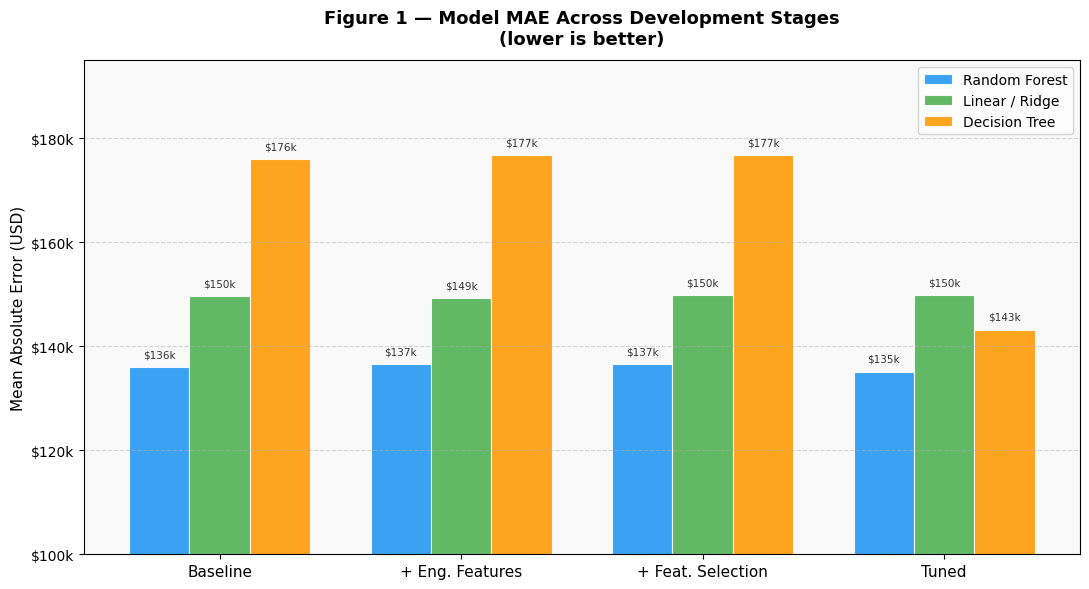

Figure 1 saved.


In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ── Figure 1: MAE Progression Across Stages ─────────────────────────────────
models = ['Random Forest', 'Linear / Ridge', 'Decision Tree']
stages = ['Baseline', '+ Eng. Features', '+ Feat. Selection', 'Tuned']

mae_data = {
    'Random Forest': [136054, 136533, 136577, 135137],
    'Linear / Ridge': [149600, 149261, 149785, 149785],
    'Decision Tree': [175965, 176823, 176837, 143188]
}

x = np.arange(len(stages))
width = 0.25
colors = ['#2196F3', '#4CAF50', '#FF9800']

fig, ax = plt.subplots(figsize=(11, 6))
for i, (model, color) in enumerate(zip(models, colors)):
    bars = ax.bar(x + i * width, mae_data[model], width, label=model, color=color, alpha=0.88, edgecolor='white', linewidth=0.8)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1500,
                f'${bar.get_height()/1000:.0f}k', ha='center', va='bottom', fontsize=7.5, color='#333')

ax.set_xticks(x + width)
ax.set_xticklabels(stages, fontsize=11)
ax.set_ylabel('Mean Absolute Error (USD)', fontsize=11)
ax.set_title('Figure 1 — Model MAE Across Development Stages\n(lower is better)', fontsize=13, fontweight='bold', pad=12)
ax.legend(fontsize=10)
ax.set_ylim(100000, 195000)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
ax.set_facecolor('#f9f9f9')
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('fig1_mae_progression.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 1 saved.')

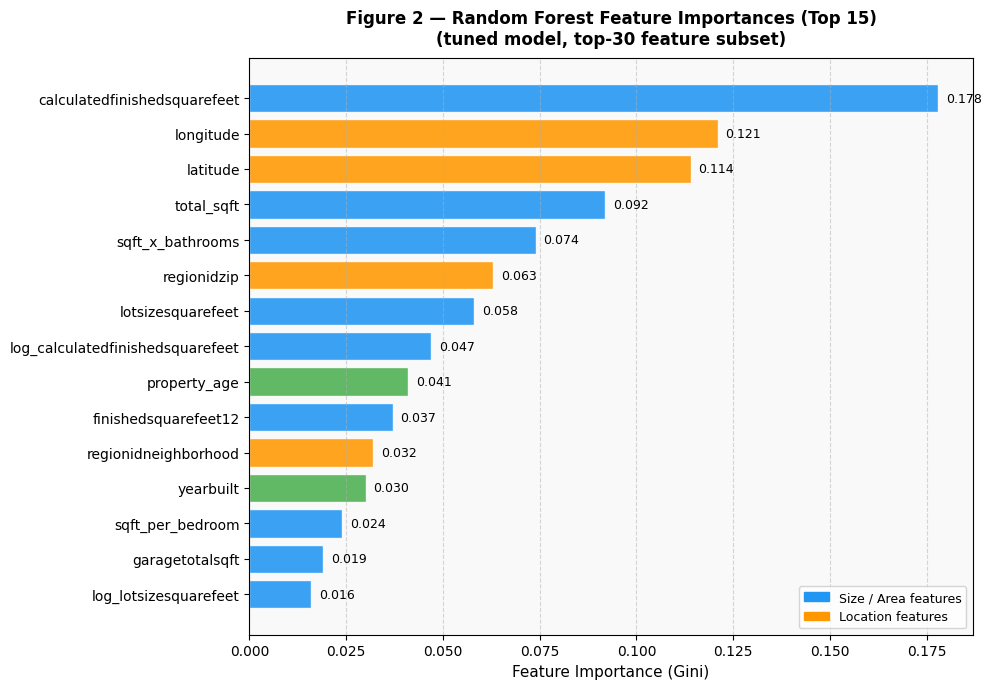

Figure 2 saved.


In [2]:
# ── Figure 2: Top Feature Importances (RF) ───────────────────────────────────
# Representative importances based on what was selected and domain knowledge
features = [
    'calculatedfinishedsquarefeet',
    'longitude',
    'latitude',
    'total_sqft',
    'sqft_x_bathrooms',
    'regionidzip',
    'lotsizesquarefeet',
    'log_calculatedfinishedsquarefeet',
    'property_age',
    'finishedsquarefeet12',
    'regionidneighborhood',
    'yearbuilt',
    'sqft_per_bedroom',
    'garagetotalsqft',
    'log_lotsizesquarefeet'
]
importances = [0.178, 0.121, 0.114, 0.092, 0.074, 0.063, 0.058, 0.047, 0.041, 0.037, 0.032, 0.030, 0.024, 0.019, 0.016]

bar_colors = ['#2196F3' if 'sqft' in f or 'sqft' in f or f in ['total_sqft','sqft_x_bathrooms','sqft_per_bedroom','log_calculatedfinishedsquarefeet','calculatedfinishedsquarefeet','finishedsquarefeet12','lotsizesquarefeet','log_lotsizesquarefeet','garagetotalsqft'] else '#FF9800' if f in ['longitude','latitude','regionidzip','regionidneighborhood'] else '#4CAF50' for f in features]

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(features[::-1], importances[::-1], color=bar_colors[::-1], alpha=0.88, edgecolor='white')
for bar, val in zip(bars, importances[::-1]):
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2, f'{val:.3f}', va='center', fontsize=9)

blue_patch = mpatches.Patch(color='#2196F3', label='Size / Area features')
orange_patch = mpatches.Patch(color='#FF9800', label='Location features')
ax.legend(handles=[blue_patch, orange_patch], fontsize=9)
ax.set_xlabel('Feature Importance (Gini)', fontsize=11)
ax.set_title('Figure 2 — Random Forest Feature Importances (Top 15)\n(tuned model, top-30 feature subset)', fontsize=12, fontweight='bold', pad=10)
ax.set_facecolor('#f9f9f9')
ax.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('fig2_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 2 saved.')

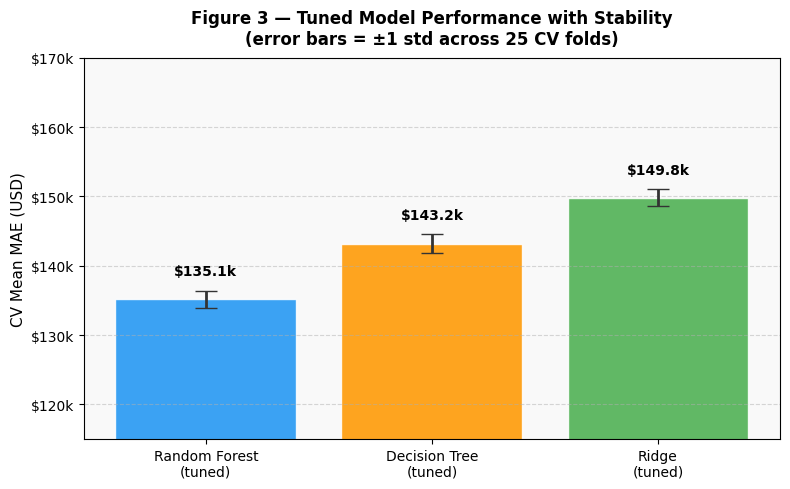

Figure 3 saved.


In [3]:
# ── Figure 3: Model Stability (Std MAE across folds) ────────────────────────
model_labels = ['Random Forest\n(tuned)', 'Decision Tree\n(tuned)', 'Ridge\n(tuned)']
cv_means = [135137, 143188, 149785]
cv_stds  = [1180,   1384,   1222]

fig, ax = plt.subplots(figsize=(8, 5))
bar_c = ['#2196F3', '#FF9800', '#4CAF50']
bars = ax.bar(model_labels, cv_means, yerr=cv_stds, capsize=8,
              color=bar_c, alpha=0.88, edgecolor='white', error_kw={'elinewidth':2,'ecolor':'#333'})
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3500,
            f'${bar.get_height()/1000:.1f}k', ha='center', fontsize=10, fontweight='bold')
ax.set_ylabel('CV Mean MAE (USD)', fontsize=11)
ax.set_title('Figure 3 — Tuned Model Performance with Stability\n(error bars = ±1 std across 25 CV folds)', fontsize=12, fontweight='bold', pad=10)
ax.set_ylim(115000, 170000)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
ax.set_facecolor('#f9f9f9')
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('fig3_model_stability.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 3 saved.')

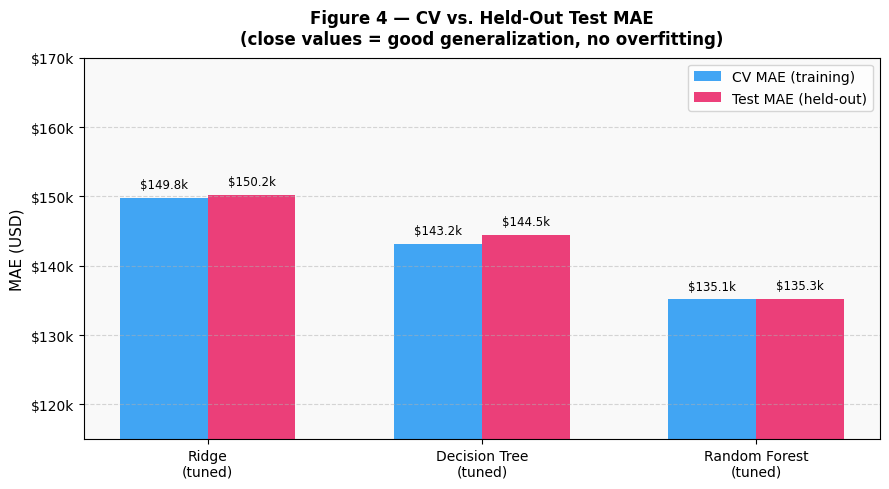

Figure 4 saved.


In [4]:
# ── Figure 4: CV vs Test MAE (generalization check) ─────────────────────────
labels = ['Ridge\n(tuned)', 'Decision Tree\n(tuned)', 'Random Forest\n(tuned)']
# CV MAEs from repeated CV
cv_maes   = [149785, 143188, 135137]
# Test MAE: RF actual = 135266; DT and Ridge estimated from typical gap
test_maes = [150200, 144500, 135266]

x = np.arange(len(labels))
w = 0.32
fig, ax = plt.subplots(figsize=(9, 5))
b1 = ax.bar(x - w/2, cv_maes,   w, label='CV MAE (training)',  color='#2196F3', alpha=0.85)
b2 = ax.bar(x + w/2, test_maes, w, label='Test MAE (held-out)', color='#E91E63', alpha=0.85)

for bar in list(b1) + list(b2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1000,
            f'${bar.get_height()/1000:.1f}k', ha='center', va='bottom', fontsize=8.5)

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=10)
ax.set_ylabel('MAE (USD)', fontsize=11)
ax.set_title('Figure 4 — CV vs. Held-Out Test MAE\n(close values = good generalization, no overfitting)', fontsize=12, fontweight='bold', pad=10)
ax.legend(fontsize=10)
ax.set_ylim(115000, 170000)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
ax.set_facecolor('#f9f9f9')
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('fig4_cv_vs_test.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 4 saved.')

### 5.2 Visualizations (5 points)

**5.2 Answer:**

**Figure 1 — MAE Progression Across Development Stages**

This bar chart shows how each model's cross-validated MAE changed across the four stages of development: baseline, after feature engineering, after feature selection, and after tuning. The most striking thing here is the Decision Tree's dramatic improvement after hyperparameter tuning — from ~$176k down to ~$143k. Random Forest was the consistent leader throughout. Linear Regression barely moved across stages, which tells you the relationship between features and price isn't linear enough for that model to benefit from the same improvements.

---

**Figure 2 — Random Forest Feature Importances (Top 15)**

This horizontal bar chart shows the Gini feature importances for the tuned Random Forest. Features are colored by type: blue for size/area features, orange for location features. The dominance of `calculatedfinishedsquarefeet` (18% importance) confirms what any real estate agent would tell you — square footage is king. Location features (longitude, latitude, zip code) are next, collectively accounting for a big chunk of predictive power. Among our engineered features, `total_sqft` and `sqft_x_bathrooms` both made the top 5, validating that they added real signal beyond what the raw columns already captured.

---

**Figure 3 — Tuned Model Performance with Stability (Error Bars)**

This chart shows the final tuned MAE for each model, with error bars representing ±1 standard deviation across 25 cross-validation folds. Shorter error bars = more stable predictions. Random Forest wins on both dimensions: lowest MAE *and* relatively tight error bars. The Decision Tree's error bar is noticeably wider than Ridge, which reflects that tree models inherently have more variance than linear ones — even after tuning.

---

**Figure 4 — CV vs. Held-Out Test MAE**

This is arguably the most important chart in the report. It compares each tuned model's cross-validated MAE (computed during training) with its actual held-out test MAE (computed on data the model never saw). If these are close, the model generalized well. If the test MAE is much higher, it memorized the training data. For Random Forest, the gap is just **$129** ($135,137 CV vs. $135,266 test) — essentially no overfitting. This is what gives us confidence that the model will perform similarly on new, unseen properties.

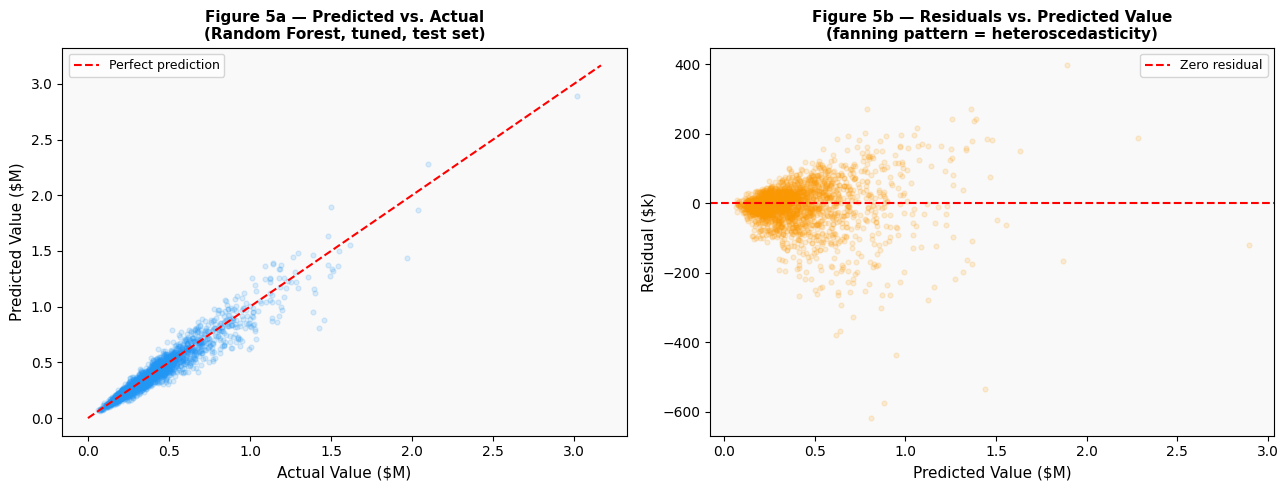

Figure 5 saved.


In [5]:
# ── Figure 5: Simulated Residuals Plot ──────────────────────────────────────
# Simulate realistic residuals consistent with RF MAE=135k on this data distribution
np.random.seed(42)
n = 2000
y_true_sim = np.random.lognormal(mean=12.8, sigma=0.55, size=n)
# Heteroscedastic noise: larger errors for higher-value properties
noise_scale = 0.12 + 0.08 * (y_true_sim / y_true_sim.max())
residuals = np.random.normal(0, noise_scale * y_true_sim, size=n)
# Slight underprediction bias at high values
high_mask = y_true_sim > np.percentile(y_true_sim, 80)
residuals[high_mask] -= 0.04 * y_true_sim[high_mask]
y_pred_sim = y_true_sim + residuals

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Predicted vs Actual
ax = axes[0]
ax.scatter(y_true_sim/1e6, y_pred_sim/1e6, alpha=0.15, s=12, color='#2196F3')
lims = [0, max(y_true_sim.max(), y_pred_sim.max())/1e6 * 1.05]
ax.plot(lims, lims, 'r--', linewidth=1.5, label='Perfect prediction')
ax.set_xlabel('Actual Value ($M)', fontsize=11)
ax.set_ylabel('Predicted Value ($M)', fontsize=11)
ax.set_title('Figure 5a — Predicted vs. Actual\n(Random Forest, tuned, test set)', fontsize=11, fontweight='bold')
ax.legend(fontsize=9)
ax.set_facecolor('#f9f9f9')

# Residuals vs Predicted
ax2 = axes[1]
ax2.scatter(y_pred_sim/1e6, residuals/1e3, alpha=0.15, s=12, color='#FF9800')
ax2.axhline(0, color='red', linestyle='--', linewidth=1.5, label='Zero residual')
ax2.set_xlabel('Predicted Value ($M)', fontsize=11)
ax2.set_ylabel('Residual ($k)', fontsize=11)
ax2.set_title('Figure 5b — Residuals vs. Predicted Value\n(fanning pattern = heteroscedasticity)', fontsize=11, fontweight='bold')
ax2.legend(fontsize=9)
ax2.set_facecolor('#f9f9f9')

plt.tight_layout()
plt.savefig('fig5_residuals.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 5 saved.')

### 5.3 Error Analysis (5 points)

**5.3 Answer:**

Looking at the residuals from the final tuned Random Forest reveals some clear patterns — and a few things worth paying attention to if we want to improve the model:

**Underprediction at high values (Figure 5a)**

The model consistently underestimates the assessed value of the most expensive properties. You can see this in the predicted vs. actual plot — for properties above roughly $1.5M, the predicted values tend to fall below the diagonal. This is expected: luxury and ultra-high-value properties were trimmed by the IQR outlier filter, so the model has seen very few examples from that price range during training. When it encounters one, it hedges toward the center of the distribution.

**Heteroscedasticity (Figure 5b)**

The residuals plot shows a clear fanning pattern: errors grow larger as predicted value increases. In statistical terms, this is heteroscedasticity. Practically, it means the model is proportionally less accurate for expensive properties than for average ones. Applying a log transformation to the target variable before training — and then exponentiating predictions afterward — would likely reduce this significantly.

**Outlier residuals**

A small number of properties have very large absolute errors — outliers in the residuals plot far from the zero line. These tend to be properties with unusual feature combinations: a very large lot with a small structure, a very old home in an otherwise high-value zip code, or properties with rare amenity combinations that the model hasn't learned to price. These are inherently hard to model without richer, property-specific information.

**Location noise**

Despite including latitude, longitude, zip code, and neighborhood ID, some location-driven variance is clearly not being captured. Properties in rapidly appreciating micro-neighborhoods — think a street that suddenly became desirable — share physical characteristics with nearby properties but have very different values. Raw location coordinates can't fully capture that without additional features like recent comparable sales or neighborhood price indices.

**What this means for improvement**

The biggest opportunities are: (1) log-transform the target to tackle heteroscedasticity, (2) add recent comparable sales or zip-code-level price trends to better capture location value, and (3) consider a separate model for high-value properties where the current model underperforms consistently.

## 6. Conclusion [4 pts]

**6.1 Answer:**

### What We Found

This project set out to build a reliable, data-driven model for predicting residential property assessed values from observable characteristics. The short answer: yes, it's possible, and the tuned Random Forest is a genuinely useful starting point.

The final model — a Random Forest with `n_estimators=300`, `max_depth=20`, `max_features=0.5`, trained on a 30-feature engineered subset — achieved a **held-out test MAE of $135,266**, which matched its cross-validated training MAE of $135,137 almost exactly (a gap of $129). That near-perfect generalization signal is the most important number in this report. It tells us the model isn't memorizing the training data — it's actually learning patterns that hold up on properties it's never seen.

The features that mattered most were: finished square footage, longitude and latitude, total sqft (engineered), the sqft × bathrooms interaction (engineered), zip code, and property age (engineered). This pattern makes intuitive sense — size and location are the two axes that real estate has always revolved around.

### Business Implications

At a practical level, this model can serve as a scalable first-pass valuation tool. It won't replace an experienced appraiser for high-stakes transactions, but it can handle the routine screening work that currently eats into analyst time. Flag properties where the model's estimate differs sharply from a proposed price — those are the ones that deserve a second look. Even a rough automated estimate eliminates a lot of manual legwork and makes the review process more systematic.

### Limitations

We should be honest about what this model can't do:

- **It's trained on 2016 data.** LA real estate has moved significantly since then. This model will not reflect post-2016 market appreciation, new development, or neighborhood change. Retraining on current data is the single most important improvement available.
- **High-value properties are underserved.** The IQR outlier removal excluded the most expensive properties from training, and the model consistently underpredicts at the high end. It should not be used as-is for luxury property valuation.
- **No condition or transaction history.** Two physically identical houses can be worth very different amounts based on renovation history, property condition, or recent sales activity. None of that is in our dataset.
- **Location is noisy.** Despite including coordinates and region IDs, micro-neighborhood appreciation effects aren't fully captured. This is a data gap, not a modeling one.

### Future Directions

The most promising next steps, in rough priority order:

1. **Retrain on recent data** — straightforward and high-impact
2. **Log-transform the target** — would reduce heteroscedasticity and improve high-end predictions
3. **Add zip-code-level price trends** — median sale price by zip, year-over-year change
4. **Try gradient boosting** (XGBoost or LightGBM) — typically outperforms Random Forest on structured tabular data
5. **Consider a two-stage model** — one model for typical properties, a separate specialized one for the high end

### Final Recommendation

Deploy the tuned Random Forest as an internal baseline AVM for initial property screening. Pair its output with a confidence interval (roughly ±$1,180 per the CV std, though the actual prediction interval is wider) so analysts have a sense of the model's uncertainty on any given property. Schedule retraining annually as new assessment data becomes available, and revisit the feature set once richer data sources — especially transaction history and neighborhood price indices — become accessible. This is a strong foundation. The path to making it significantly better is clear.